# Nonlinearly coupled oscillators


$$ \begin{cases} \dot{q}_1 = p_1 \qquad & \dot{p}_1 = -q_1 - \varepsilon \partial_{q_1} U(q_1,q_2) \\ \dot{q}_2 = \varepsilon p_2 \qquad & \dot{p}_2 = -\varepsilon q_2 - \varepsilon \partial_{q_2} U(q_1,q_2)
\end{cases} $$

$$ H_\varepsilon (q_1,q_2,p_1,p_2) = \frac{1}{2} (q_1^2 + p_1^2 ) + \frac{1}{2} \varepsilon (q_2^2 + p_2^2 )  + \varepsilon U(q_1,q_2)    $$

$$ U(q_1,q_2) = q_1 q_2 \sin(2q_1 + 2q_2)$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from dataprocessing_utils.nco import NCO, NCOTrajectory, NCODataset, REF_TRAJ_DT, REF_TRAJ_FILEPATHS

Trajectory = NCOTrajectory
Dataset = NCODataset

In [2]:
print(plt.rcParams)

_internal.classic_mode: False
agg.path.chunksize: 0
animation.bitrate: -1
animation.codec: h264
animation.convert_args: ['-layers', 'OptimizePlus']
animation.convert_path: convert
animation.embed_limit: 20.0
animation.ffmpeg_args: []
animation.ffmpeg_path: ffmpeg
animation.frame_format: png
animation.html: none
animation.writer: ffmpeg
axes.autolimit_mode: data
axes.axisbelow: line
axes.edgecolor: black
axes.facecolor: white
axes.formatter.limits: [-5, 6]
axes.formatter.min_exponent: 0
axes.formatter.offset_threshold: 4
axes.formatter.use_locale: False
axes.formatter.use_mathtext: False
axes.formatter.useoffset: True
axes.grid: False
axes.grid.axis: both
axes.grid.which: major
axes.labelcolor: black
axes.labelpad: 4.0
axes.labelsize: medium
axes.labelweight: normal
axes.linewidth: 0.8
axes.prop_cycle: cycler('color', ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'])
axes.spines.bottom: True
axes.spines.left: True
axes.spines

In [3]:
font = {'family' : 'sans-serif',
        'weight' : 'normal',
        'size'   : 6}
axes = {'linewidth' : 0.4}
lines = {'linewidth' : 0.4}
mathtext = {'fontset' : 'cm'}
xtick = {'labelsize': 'small',
         'major.size': 2,
         'minor.size': 1}
ytick = {'labelsize': 'small',
         'major.size': 2,
         'minor.size': 1}

plt.rc('font', **font)
plt.rc('axes', **axes)
plt.rc('lines', **lines)
plt.rc('mathtext', **mathtext)
plt.rc('xtick', **xtick)
plt.rc('ytick', **ytick)

In [14]:
# Plotting functions

def plot_phase_space(trajs, axis_lims=None, linestyles=None, legend_labels=None, axis_labels=None, 
                     titles=None, figsize=(9, 3), show_legend=False, save_path=None):
    
    if linestyles is None:
        linestyles = ['-'] * len(trajs)  # Default linestyle for all plots
    
    if legend_labels is None:
        legend_labels = ['Trajectory {}'.format(i+1) for i in range(len(trajs))]  # Default labels for legends

    if axis_labels is None:
        axis_labels = [('$q_1$', '$p_1$'), ('$q_2$', '$p_2$')]  # Default axis labels

    if titles is None:
        titles = ['Oscillator 1', 'Oscillator 2']  # Default titles for subplots

    fig, axes = plt.subplots(1, 2, figsize=figsize, layout='constrained')  # Use plt.subplots to manage multiple axes

    lines = []  # List to hold the line objects for the legend
    for traj, linestyle, legend_label in zip(trajs, linestyles, legend_labels):
        p1, p2, q1, q2 = traj.states.get_pq()
        if legend_label == 'ref':
            line1, = axes[0].plot(q1, p1, linestyle, lw=1, color='k', alpha=0.3, label=legend_label)
            axes[1].plot(q2, p2, linestyle, lw=1, color='k', alpha=0.3)
        else:
            line1, = axes[0].plot(q1, p1, linestyle, lw=1, label=legend_label)
            axes[1].plot(q2, p2, linestyle, lw=1)
        lines.append(line1)  # Append the line object for the legend
        

    # Set labels and titles for each subplot
    for i, ax in enumerate(axes):
        if axis_lims is not None:
            ax.set_xlim(axis_lims[i][0])
            ax.set_ylim(axis_lims[i][1])
        ax.set_xlabel(axis_labels[i][0])
        ax.set_ylabel(axis_labels[i][1])
        ax.set_title(titles[i])

    if show_legend:
        # Place a single legend outside the right of the subplots
        fig.legend(lines, legend_labels, loc='outside center right', borderaxespad=0.1)
        # plt.subplots_adjust(right=0.85)  # Adjust the right boundary of the subplots to make room for the legend

    # plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format='png', dpi=300)  # Save the figure to the specified path
        print(f"Figure saved as '{save_path}'")
    else:
        plt.show()

    return

def plot_errors(trajs, ref_trajs, linestyles=None, legend_labels=None, titles=None, error_names=None, 
                ylims=None, ylabels=None, figsize=(9, 3), log_yscale=True, show_legend=False, save_path=None):
    
    if isinstance(ref_trajs, Trajectory):
        ref_trajs = [ref_trajs] * len(trajs)
    elif isinstance(ref_trajs, list):
        assert len(trajs) == len(ref_trajs), "Number of trajs and ref_trajs must be the same"
    else:
        raise ValueError("ref_trajs must be a Trajectory or a list of Trajectories")

    if linestyles is None:
        linestyles = ['-'] * len(trajs)  # Default linestyle for all plots
    
    if legend_labels is None:
        legend_labels = ['Trajectory {}'.format(i+1) for i in range(len(trajs))]  # Default labels for legends
    
    if titles is None:
        titles = ['Oscillator 1 traj error', 'Oscillator 2 traj error', 'Traj error', 'H error']  # Default titles for subplots

    if error_names is None:
        error_names = ["osc1_rel_traj_err", "osc2_rel_traj_err", "rel_traj_err", "rel_H_err"]
    
    if ylims is None:
        ylims = [(1e-4, 1e0)] * 4  # Default ylims for subplots
    
    if ylabels is None:
        ylabels = ['rel err'] * 4  # Default y axis labels

    fig, axes = plt.subplots(2, 2, figsize=figsize, layout='constrained')  # Use plt.subplots to manage multiple axes

    lines = []  # List to hold the line objects for the legend
    for traj, ref_traj, linestyle, legend_label in zip(trajs, ref_trajs, linestyles, legend_labels):
        tt, errors = Trajectory.compare(traj, ref_traj)
        line1, = axes[0, 0].plot(tt, errors[error_names[0]], linestyle, lw=1, label=legend_label)
        axes[0, 1].plot(tt, errors[error_names[1]], linestyle, lw=1)
        axes[1, 0].plot(tt, errors[error_names[2]], linestyle, lw=1)
        axes[1, 1].plot(tt, errors[error_names[3]], linestyle, lw=1)
        lines.append(line1)  # Append the line object for the legend

    # Set labels and titles for each subplot
    for i, ax in enumerate(axes.flatten()):
        ax.set_ylim(ylims[i])
        ax.set_xlabel('$t$')
        ax.set_ylabel(ylabels[i])
        ax.set_title(titles[i])
        if log_yscale:
            ax.set_yscale('log')

    if show_legend:
        # Place a single legend outside the right of the subplots
        fig.legend(lines, legend_labels, loc='outside center right', borderaxespad=0.1)
        # plt.subplots_adjust(right=0.85)  # Adjust the right boundary of the subplots to make room for the legend

    # plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format='png', dpi=300)  # Save the figure to the specified path
        print(f"Figure saved as '{save_path}'")
    else:
        plt.show()

    return fig

def plot_pq_vs_t(trajs, linestyles=None, legend_labels=None, ylabels=None, ylims=None, figsize=(9, 3), 
                 show_legend=False, save_path=None):
    
    if linestyles is None:
        linestyles = ['-'] * len(trajs)  # Default linestyle for all plots
    
    if legend_labels is None:
        legend_labels = ['Trajectory {}'.format(i+1) for i in range(len(trajs))]  # Default labels for legends
    
    if ylabels is None:
        ylabels = ['$q_1$', '$q_2$', '$p_1$', '$p_2$']  # Default y axis labels

    if ylims is None:
        ylims = [(None, None)] * 4

    fig, axes = plt.subplots(2, 2, figsize=figsize, layout='constrained')  # Use plt.subplots to manage multiple axes

    lines = []  # List to hold the line objects for the legend
    for traj, linestyle, legend_label in zip(trajs, linestyles, legend_labels):
        p1, p2, q1, q2 = traj.states.get_pq()
        if legend_label == 'ref':
            line1, = axes[0, 0].plot(traj.times, q1, linestyle, lw=1, color='k', alpha=0.3, label=legend_label)
            axes[0, 1].plot(traj.times, q2, linestyle, lw=1, color='k', alpha=0.3)
            axes[1, 0].plot(traj.times, p1, linestyle, lw=1, color='k', alpha=0.3)
            axes[1, 1].plot(traj.times, p2, linestyle, lw=1, color='k', alpha=0.3)
        else:
            line1, = axes[0, 0].plot(traj.times, q1, linestyle, lw=1, label=legend_label)
            axes[0, 1].plot(traj.times, q2, linestyle, lw=1)
            axes[1, 0].plot(traj.times, p1, linestyle, lw=1)
            axes[1, 1].plot(traj.times, p2, linestyle, lw=1)
        lines.append(line1)  # Append the line object for the legend

    # Set labels and titles for each subplot
    for i, ax in enumerate(axes.flatten()):
        ax.set_ylim(ylims[i])
        ax.set_xlabel('$t$')
        ax.set_ylabel(ylabels[i])

    if show_legend:
        # Place a single legend outside the right of the subplots
        fig.legend(lines, legend_labels, loc='outside center right', borderaxespad=0.1)
        # plt.subplots_adjust(right=0.85)  # Adjust the right boundary of the subplots to make room for the legend

    # plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format='png', dpi=300)  # Save the figure to the specified path
        print(f"Figure saved as '{save_path}'")
    else:
        plt.show()

    return

def plot_pq_errors(trajs, ref_trajs, linestyles=None, legend_labels=None, 
                ylims=None, ylabels=None, figsize=(9, 3), log_yscale=True, show_legend=False, save_path=None):
    
    if isinstance(ref_trajs, Trajectory):
        ref_trajs = [ref_trajs] * len(trajs)
    elif isinstance(ref_trajs, list):
        assert len(trajs) == len(ref_trajs), "Number of trajs and ref_trajs must be the same"
    else:
        raise ValueError("ref_trajs must be a Trajectory or a list of Trajectories")

    if linestyles is None:
        linestyles = ['-'] * len(trajs)  # Default linestyle for all plots
    
    if legend_labels is None:
        legend_labels = ['Trajectory {}'.format(i+1) for i in range(len(trajs))]  # Default labels for legends

    if ylims is None:
        ylims = [(1e-4, 1e0)] * 4  # Default ylims for subplots
    
    if ylabels is None:
        ylabels = ['$q_1$ error', '$q_2$ error', '$p_1$ error', '$p_2$ error']  # Default y axis labels

    fig, axes = plt.subplots(2, 2, figsize=figsize, layout='constrained')  # Use plt.subplots to manage multiple axes

    lines = []  # List to hold the line objects for the legend
    for traj, ref_traj, linestyle, legend_label in zip(trajs, ref_trajs, linestyles, legend_labels):
        matched_traj, matched_ref_traj = Trajectory.intersect(traj, ref_traj)
        tt = matched_traj.times
        p1, p2, q1, q2 = matched_traj.states.get_pq()
        p1_ref, p2_ref, q1_ref, q2_ref = matched_ref_traj.states.get_pq()
        line1, = axes[0, 0].plot(tt, np.abs(q1-q1_ref), linestyle, lw=1, label=legend_label)
        axes[0, 1].plot(tt, np.abs(q2-q2_ref), linestyle, lw=1)
        axes[1, 0].plot(tt, np.abs(p1-p1_ref), linestyle, lw=1)
        axes[1, 1].plot(tt, np.abs(p2-p2_ref), linestyle, lw=1)
        lines.append(line1)  # Append the line object for the legend

    # Set labels and titles for each subplot
    for i, ax in enumerate(axes.flatten()):
        ax.set_ylim(ylims[i])
        ax.set_xlabel('$t$')
        ax.set_ylabel(ylabels[i])
        if log_yscale:
            ax.set_yscale('log')

    if show_legend:
        # Place a single legend outside the right of the subplots
        fig.legend(lines, legend_labels, loc='outside center right', borderaxespad=0.1)
        # plt.subplots_adjust(right=0.85)  # Adjust the right boundary of the subplots to make room for the legend

    # plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format='png', dpi=300)  # Save the figure to the specified path
        print(f"Figure saved as '{save_path}'")
    else:
        plt.show()

    return fig

def plot_trace(trajs, func_dict, linestyles=None, alpha=1., legend_labels=None, ylabels=None, ylims=None, 
               figsize=None, show_legend=False, save_path=None):
    
    if linestyles is None:
        linestyles = ['-'] * len(trajs)  # Default linestyle for all plots
    
    if legend_labels is None:
        legend_labels = ['Trajectory {}'.format(i+1) for i in range(len(trajs))]  # Default labels for legends
    
    if ylabels is None:
        ylabels = list(func_dict.keys())  # Default y axis labels

    if ylims is None:
        ylims = [(None, None)] * len(func_dict)
    
    if figsize is None:
        figsize = (8, 1.5 * len(func_dict))

    fig, axes = plt.subplots(len(func_dict), 1, figsize=figsize, layout='constrained')  # Use plt.subplots to manage multiple axes

    lines = []  # List to hold the line objects for the legend
    for traj, linestyle, legend_label in zip(trajs, linestyles, legend_labels):
        for i, (key, func) in enumerate(func_dict.items()):
            if len(func_dict) > 1:
                line1, = axes[i].plot(traj.times, func(traj.states.u), linestyle, lw=1, alpha=alpha, label=legend_label)
            else:
                line1, = axes.plot(traj.times, func(traj.states.u), linestyle, lw=1, alpha=alpha, label=legend_label)
        lines.append(line1) # Append the line object for the legend

    # Set labels and titles for each subplot
    if len(func_dict) > 1:
        for i, ax in enumerate(axes):
            ax.set_ylim(ylims[i])
            ax.set_xlabel('$t$')
            ax.set_ylabel(ylabels[i])
    else:
        axes.set_ylim(ylims[0])
        axes.set_xlabel('$t$')
        axes.set_ylabel(ylabels[0])

    if show_legend:
        # Place a single legend outside the right of the subplots
        fig.legend(lines, legend_labels, loc='outside center right', borderaxespad=0.1)
        # plt.subplots_adjust(right=0.85)  # Adjust the right boundary of the subplots to make room for the legend

    # plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format='png', dpi=300)  # Save the figure to the specified path
        print(f"Figure saved as '{save_path}'")
    else:
        plt.show()

    return 

In [5]:
def plot_phase_space_oscillator2(trajs, axis_lims=None, linestyles=None, colors=None, legend_labels=None, axis_labels=None, 
                     title=None, figsize=(2, 1.6), show_legend=False, save_path=None):
    
    if linestyles is None:
        linestyles = ['-'] * len(trajs)  # Default linestyle for all plots
    
    if colors is None:
        colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 
                  'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan']  # Default colors for all plots

    if legend_labels is None:
        legend_labels = ['Trajectory {}'.format(i+1) for i in range(len(trajs))]  # Default labels for legends

    if axis_labels is None:
        axis_labels = ('$q_2$', '$p_2$')  # Default axis labels

    if title is None:
        title = 'Oscillator 2'  # Default titles for subplots

    fig, ax = plt.subplots(1, 1, figsize=figsize, layout='constrained')  # Use plt.subplots to manage multiple axes

    for traj, linestyle, color, legend_label in zip(trajs, linestyles, colors, legend_labels):
        _, p2, _, q2 = traj.states.get_pq()
        if legend_label == 'ref':
            ax.plot(q2, p2, linestyle, color='k', alpha=0.3, label=legend_label)
        else:
            ax.plot(q2, p2, linestyle, color=color, label=legend_label)
        

    # Set labels and titles for each subplot
    if axis_lims is not None:
        ax.set_xlim(axis_lims[0])
        ax.set_ylim(axis_lims[1])
    ax.set_xlabel(axis_labels[0])
    ax.set_ylabel(axis_labels[1])
    ax.set_title(title)

    if show_legend:
        # Place a single legend outside the right of the subplots
        fig.legend(legend_labels, loc='outside center right', borderaxespad=0.1)
        # plt.subplots_adjust(right=0.85)  # Adjust the right boundary of the subplots to make room for the legend

    # plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format='pdf', dpi=300)  # Save the figure to the specified path
        print(f"Figure saved as '{save_path}'")
    else:
        plt.show()

    return

## Given target $H$, find unknown variable

In [3]:
from scipy.optimize import fsolve

def find_unknown(H, target_H, knowns, unknown_var):
    """
    Find the unknown variable in the equation H(v1, v2, x1, x2) = target_H.

    Args:
    - H (callable): The function H(v1, v2, x1, x2).
    - target_H (float): The known value of H.
    - knowns (dict): A dictionary with keys as variable names and values as their values. Should contain exactly three items.
    - unknown_var (str): The name of the unknown variable (one of 'v1', 'v2', 'x1', 'x2').

    Returns:
    - float: The computed value of the unknown variable that makes H equal to target_H.
    """
    # Check input validity
    assert len(knowns) == 3 and unknown_var not in knowns, "There must be exactly three known variables."

    # Define the function to find the root
    def func(unknown):
        vars = knowns.copy()
        vars[unknown_var] = unknown[0]
        inputs = np.array([vars['v1'], vars['v2'], vars['x1'], vars['x2']])
        return H(inputs) - target_H

    # Initial guess for the unknown
    initial_guess = [0.1]

    # Solve for the unknown
    solution = fsolve(func, initial_guess)
    error = func(solution)

    return solution[0], error

In [4]:
# Known values and target
target_value = NCO().compute_hamiltonian(np.array([[0.0, 0.0, 1.5, 1.5]]))[0]
known_values = {"v1": 1.0, "x1": 0.0, "x2": 0.0}
print(f"Target value of H is: {target_value}")
print(f"Known values are: {known_values}")

# Find unknown 
unknown_var = "v2"
result, error = find_unknown(lambda u: NCO().compute_hamiltonian(u), target_value, known_values, unknown_var)
print(f"The value of {unknown_var} that satisfies the equation is: {result}")
print(f"The error (residual) of the solution is: {error}")

Target value of H is: 1.1299631512905242
Known values are: {'v1': 1.0, 'x1': 0.0, 'x2': 0.0}
The value of v2 that satisfies the equation is: 0.11224643881126242
The error (residual) of the solution is: -2.220446049250313e-16


## Compute and visualize $(q_2, p_2)$ level sets

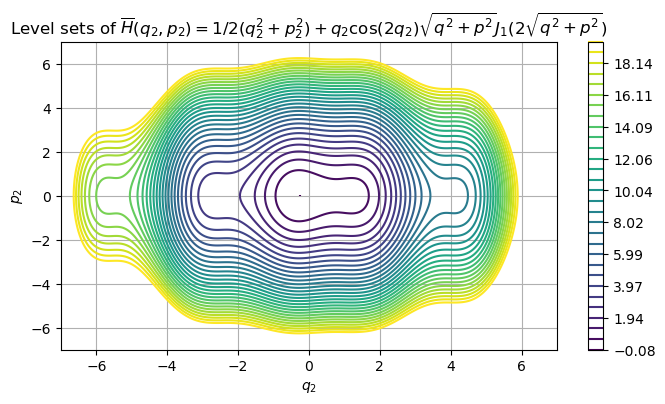

In [2]:
from scipy.special import j1

def averaged_hamiltonian(q2, p2, q, p):
    r = np.sqrt(q**2 + p**2)
    fac = r * j1(2*r)
    return 0.5 * (q2**2 + p2**2) + q2 * np.cos(2 * q2) * fac

# Create a grid of (q2, p2) values
q2 = np.linspace(-7, 7, 400)
p2 = np.linspace(-7, 7, 400)
Q, P = np.meshgrid(q2, p2)

# Calculate H_bar for each (q2, p2) pair
H = averaged_hamiltonian(Q, P, q=1.5, p=0)

# Plot the level sets
plt.figure(figsize=(8, 4))
levels = np.linspace(H.min(), H.max()-30, 30)
# levels = [0., 0.084, 0.171, 0.222, 0.288, 0.335, 0.414, 4., 10.]
contour = plt.contour(Q, P, H, levels=levels, cmap='viridis')
plt.colorbar(contour)
plt.title('Level sets of $\overline{H}(q_2, p_2) = 1/2 (q_2^2 + p_2^2) + q_2 \cos(2q_2) \sqrt{q^2 + p^2} J_1(2\sqrt{q^2 + p^2})$')
plt.xlabel('$q_2$')
plt.ylabel('$p_2$')
plt.grid(True)
plt.show()

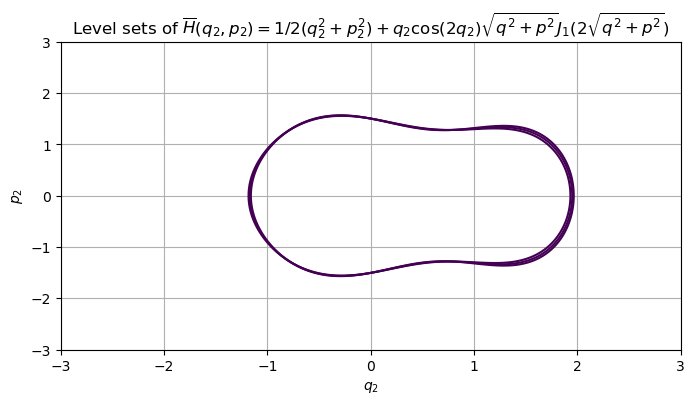

In [3]:
E = 1.129

q2 = np.linspace(-3, 3, 400)
p2 = np.linspace(-3, 3, 400)
Q, P = np.meshgrid(q2, p2)

plt.figure(figsize=(8, 4))

for (q, p) in [(1.5, 0), (-1.45, 0), (1., 0)]: 
    H = averaged_hamiltonian(Q, P, q=q, p=p)
    contour = plt.contour(Q, P, H, levels=[E], cmap='viridis')
    # plt.colorbar(contour)
plt.title('Level sets of $\overline{H}(q_2, p_2) = 1/2 (q_2^2 + p_2^2) + q_2 \cos(2q_2) \sqrt{q^2 + p^2} J_1(2\sqrt{q^2 + p^2})$')
plt.xlabel('$q_2$')
plt.ylabel('$p_2$')
plt.grid(True)
plt.show()

Target value of H is: 1.1299631512905242
Known values are: {'v1': 1.0, 'x1': 0.0, 'x2': 0.0}
The value of v2 that satisfies the equation is: 0.11224643881126242
The error (residual) of the solution is: -2.220446049250313e-16


## Reference trajectories with $u(0) = [0, 0, 1.5, q_2(0)]$

In [5]:
# Global variables for the NCO reference trajectories

TRAJ_INDICES_DIFF_Q2 = {2, 3, 4, 5, 6, 7, 8, 13, 14, 15, 16}

for idx in TRAJ_INDICES_DIFF_Q2:
    ref_traj = Trajectory.load_from_file(REF_TRAJ_FILEPATHS[idx], dt=REF_TRAJ_DT)
    print(f"Traj {idx}: {ref_traj}, H = {NCO().compute_hamiltonian(ref_traj.uu[0])}")

Traj 2: Trajectory(t_range=[0.0, 2000.0], dt=0.05, length=40001, u0=[0.  0.  1.5 0. ]), H = 1.125
Traj 3: Trajectory(t_range=[0.0, 2000.0], dt=0.05, length=40001, u0=[0.   0.   1.5  0.15]), H = 1.1247575721881777
Traj 4: Trajectory(t_range=[0.0, 2000.0], dt=0.05, length=40001, u0=[0.  0.  1.5 0.3]), H = 1.1234586580051733
Traj 5: Trajectory(t_range=[0.0, 2000.0], dt=0.05, length=40001, u0=[0.  0.  1.5 0.4]), H = 1.1221288526543436
Traj 6: Trajectory(t_range=[0.0, 2000.0], dt=0.05, length=40001, u0=[0.  0.  1.5 1. ]), H = 1.1156161358800527
Traj 7: Trajectory(t_range=[0.0, 2000.0], dt=0.05, length=40001, u0=[0.   0.   1.5  1.45]), H = 1.1273806825399424
Traj 8: Trajectory(t_range=[0.0, 2000.0], dt=0.05, length=40001, u0=[0.   0.   1.5  1.55]), H = 1.1327772217756737
Traj 13: Trajectory(t_range=[0.0, 2000.0], dt=0.05, length=40001, u0=[0.  0.  1.5 4. ]), H = 1.1450005876069578
Traj 14: Trajectory(t_range=[0.0, 2000.0], dt=0.05, length=40001, u0=[0.  0.  1.5 5. ]), H = 1.281512527761998
T

In [6]:
# Plotting function for reference trajectories

def plot_reference_trajs(traj_indices, t_range=None, phase_space_axis_lims=None, colors=None, save_path=None):

    # Load the reference trajectories
    trajs = [Trajectory.load_from_file(REF_TRAJ_FILEPATHS[idx], REF_TRAJ_DT) for idx in traj_indices]
    legend_labels = [f"u0={traj.states.u[0]}" for traj in trajs]

    # Select a time range if specified"
    if t_range is not None:
        trajs = [traj.select_between(*t_range) for traj in trajs]

    if save_path is not None:
        phase_space_oscillator2_save_path = save_path + "/phase_space_osc2.pdf"
    else:
        phase_space_oscillator2_save_path = None

    # Plot the phase space
    plot_phase_space_oscillator2(trajs, colors=colors, axis_lims=phase_space_axis_lims[1], title="$\phi$", show_legend=False, 
                                 save_path=phase_space_oscillator2_save_path)
    plot_phase_space(trajs, axis_lims=phase_space_axis_lims, 
                     legend_labels=legend_labels, show_legend=True)
    
    # Plot phase space variables vs time
    q1_lim, p1_lim = phase_space_axis_lims[0]
    q2_lim, p2_lim = phase_space_axis_lims[1]
    plot_pq_vs_t(trajs, ylims=[q1_lim, q2_lim, p1_lim, p2_lim],
                 legend_labels=legend_labels, show_legend=True)

    return

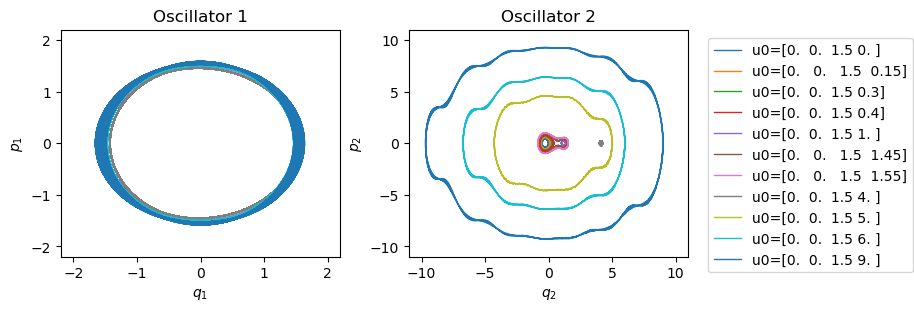

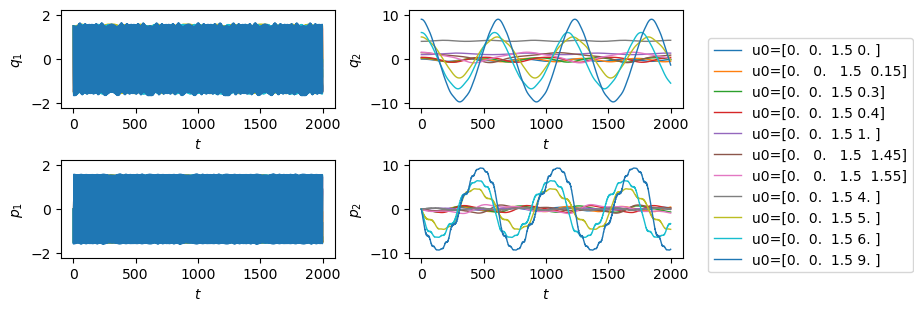

In [7]:
traj_indices = TRAJ_INDICES_DIFF_Q2
phase_space_axis_lims = [[(-2.2, 2.2), (-2.2, 2.2)], [(-11, 11), (-11, 11)]]

plot_reference_trajs(
    traj_indices, t_range=(0, 2000), phase_space_axis_lims=phase_space_axis_lims,
)


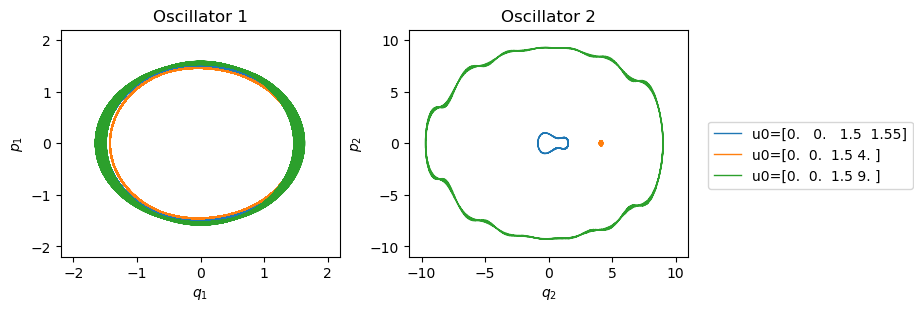

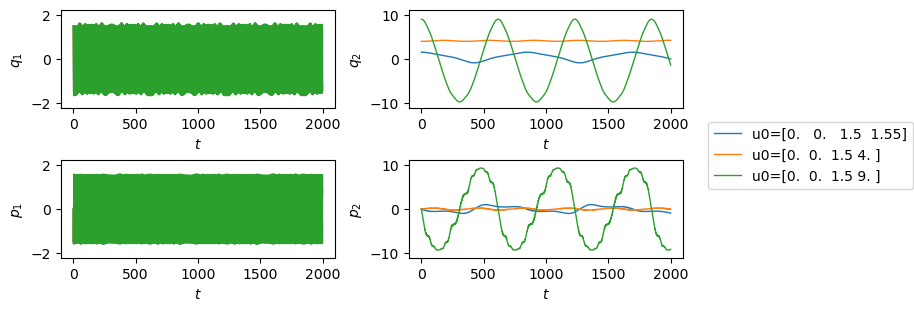

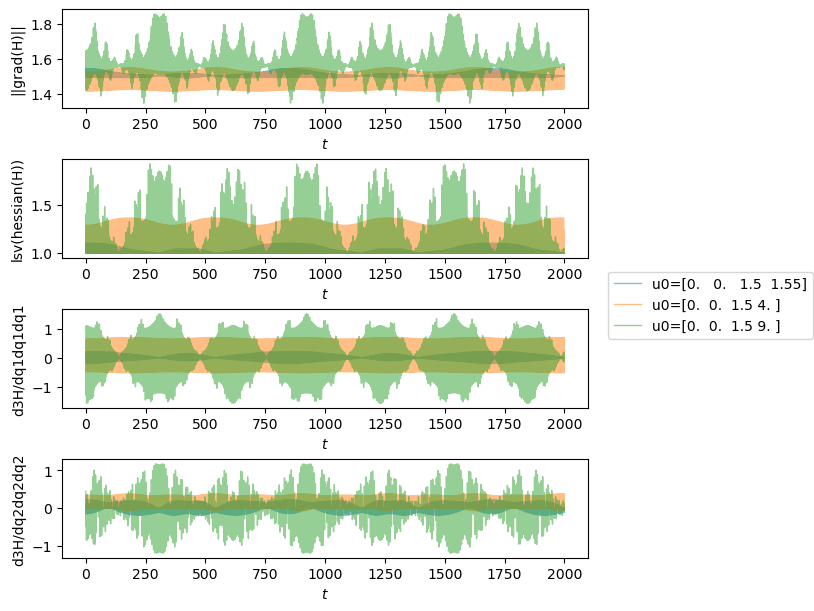

In [8]:
traj_indices = [8, 13, 16]
trajs = [Trajectory.load_from_file(REF_TRAJ_FILEPATHS[idx], REF_TRAJ_DT) for idx in traj_indices]
legend_labels = [f"u0={traj.uu[0]}" for traj in trajs]

plot_reference_trajs(
    traj_indices, t_range=(0, 2000), phase_space_axis_lims=phase_space_axis_lims,
)

nco = NCO()
func_dict = {
    "||grad(H)||": lambda u: np.linalg.norm(nco.compute_grad_H(u), axis=-1),
    "lsv(hessian(H))": lambda u: np.linalg.svd(nco.compute_hessian_H(u), compute_uv=False)[:, 0],
    # "d2H/dq1dq1": lambda u: nco.compute_hessian_H(u)[:, 2, 2],
    # "d2H/dq2dq2": lambda u: nco.compute_hessian_H(u)[:, 3, 3],
    # "d2H/dq1dq2": lambda u: nco.compute_hessian_H(u)[:, 2, 3],
    "d3H/dq1dq1dq1": nco.compute_d3Hdq1dq1dq1,
    "d3H/dq2dq2dq2": nco.compute_d3Hdq2dq2dq2,
    # "H": nco.compute_hamiltonian,
    # "V": nco.compute_potential_energy,
    # "K": nco.compute_kinetic_energy,
    # "V12": nco.compute_interaction_energy
}

plot_trace(trajs, func_dict, alpha=0.5, legend_labels=legend_labels, show_legend=True)

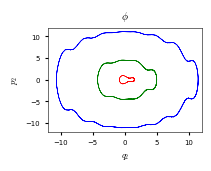

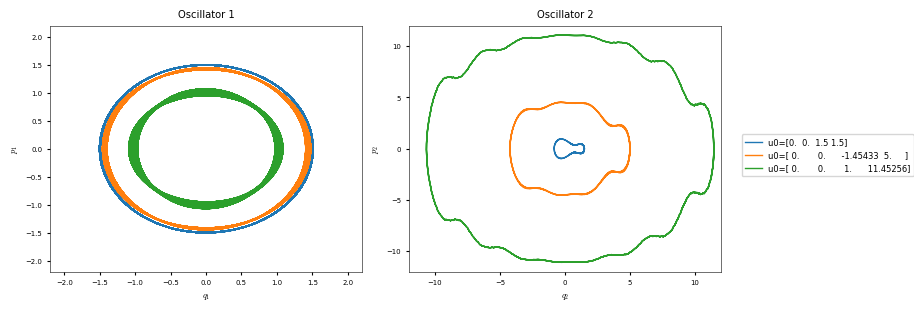

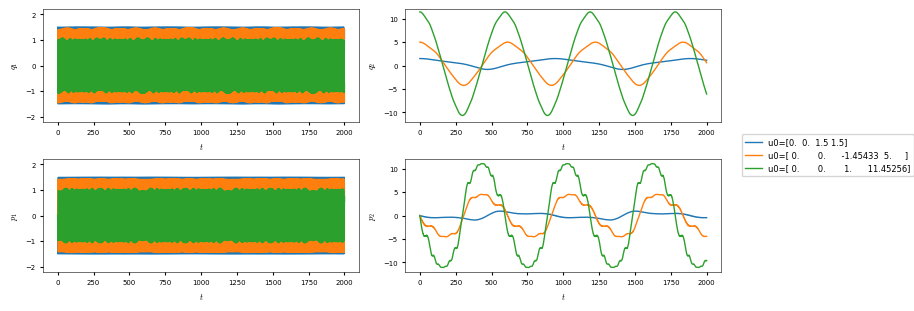

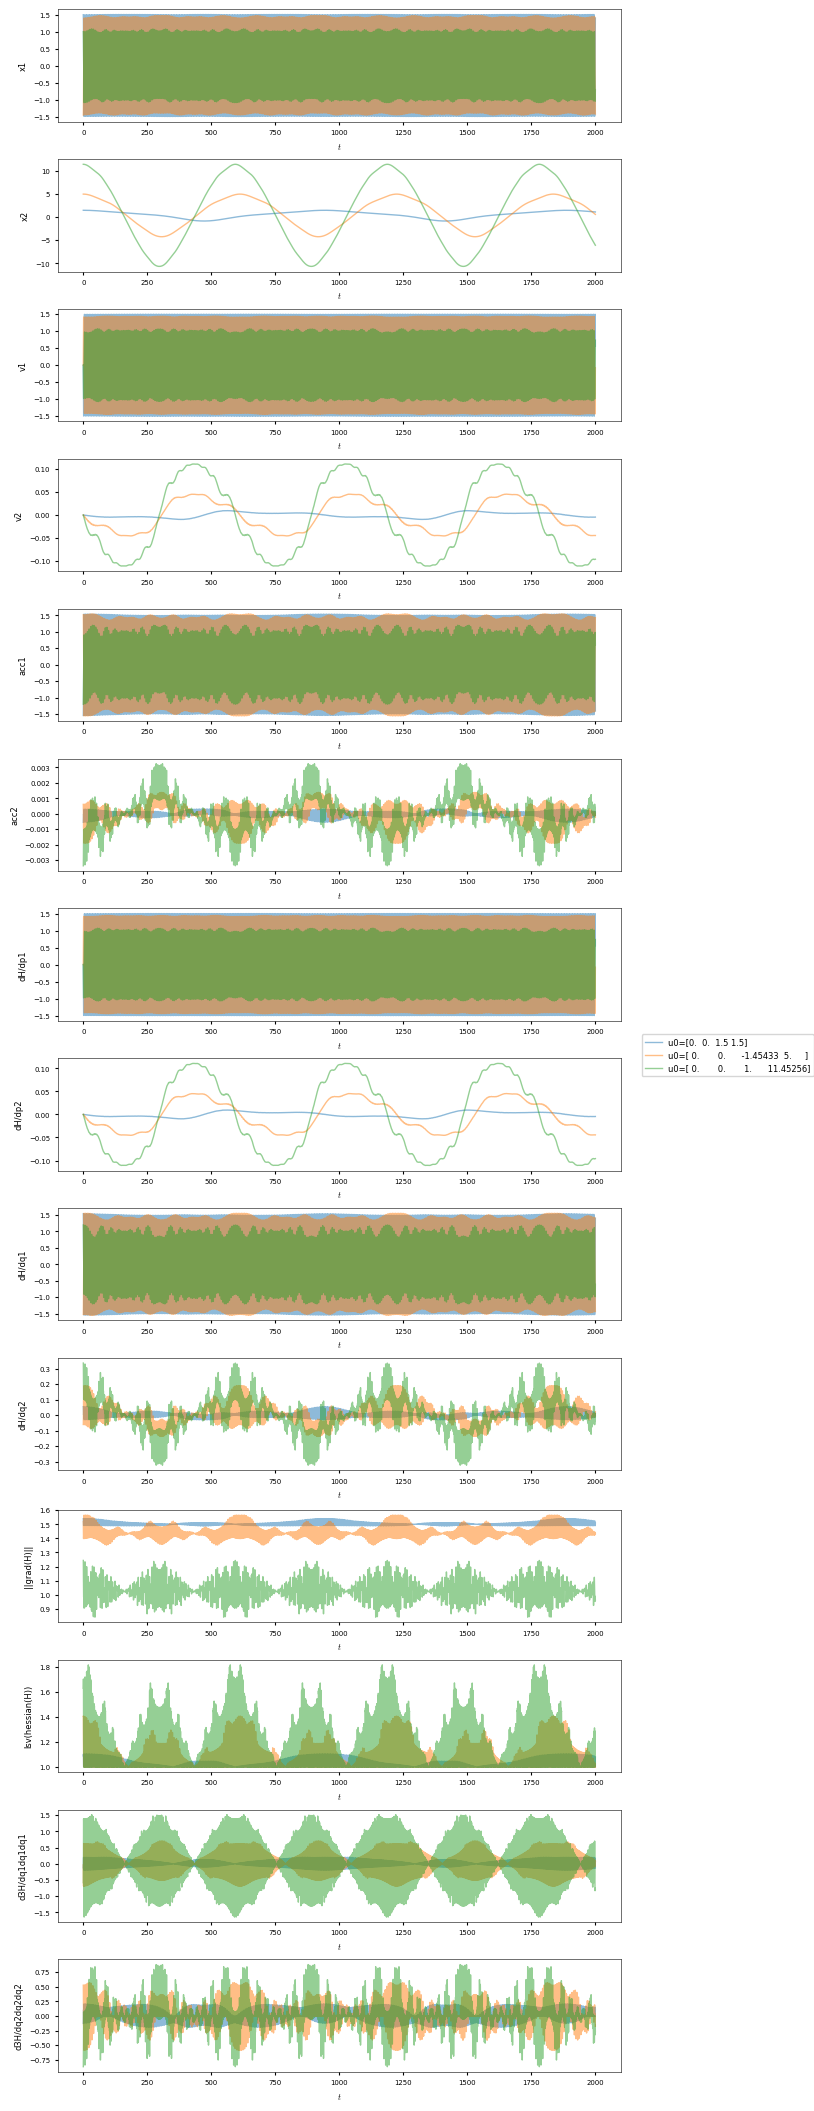

In [8]:
traj_indices = [1, 12, 11]
trajs = [Trajectory.load_from_file(REF_TRAJ_FILEPATHS[idx], REF_TRAJ_DT) for idx in traj_indices]
legend_labels = [f"u0={traj.states.u[0]}" for traj in trajs]
phase_space_axis_lims = [[(-2.2, 2.2), (-2.2, 2.2)], [(-12, 12), (-12, 12)]]
colors = ['r', 'g', 'b']

plot_reference_trajs(
    traj_indices, t_range=(0, 2000), colors=colors, phase_space_axis_lims=phase_space_axis_lims, 
    # save_path="./out"
)

nco = NCO()
func_dict = {
    "x1": lambda u: u[:, 2],
    "x2": lambda u: u[:, 3],
    "v1": lambda u: u[:, 0],
    "v2": lambda u: u[:, 1],
    "acc1": lambda u: nco.compute_ddx(u)[:, 0],
    "acc2": lambda u: nco.compute_ddx(u)[:, 1],
    "dH/dp1": lambda u: nco.compute_grad_H(u)[:, 0],
    "dH/dp2": lambda u: nco.compute_grad_H(u)[:, 1],
    "dH/dq1": lambda u: nco.compute_grad_H(u)[:, 2],
    "dH/dq2": lambda u: nco.compute_grad_H(u)[:, 3],
    "||grad(H)||": lambda u: np.linalg.norm(nco.compute_grad_H(u), axis=-1),
    "lsv(hessian(H))": lambda u: np.linalg.svd(nco.compute_hessian_H(u), compute_uv=False)[:, 0],
    # "d2H/dq1dq1": lambda u: nco.compute_hessian_H(u)[:, 2, 2],
    # "d2H/dq2dq2": lambda u: nco.compute_hessian_H(u)[:, 3, 3],
    # "d2H/dq1dq2": lambda u: nco.compute_hessian_H(u)[:, 2, 3],
    "d3H/dq1dq1dq1": nco.compute_d3Hdq1dq1dq1,
    "d3H/dq2dq2dq2": nco.compute_d3Hdq2dq2dq2,
    # "H": nco.compute_hamiltonian,
    # "V": nco.compute_potential_energy,
    # "K": nco.compute_kinetic_energy,
    # "V12": nco.compute_interaction_energy
}

trajs = [traj.select_between(0, 2000) for traj in trajs]
plot_trace(trajs, func_dict, alpha=0.5, legend_labels=legend_labels, show_legend=True)

## Curvature of $H$

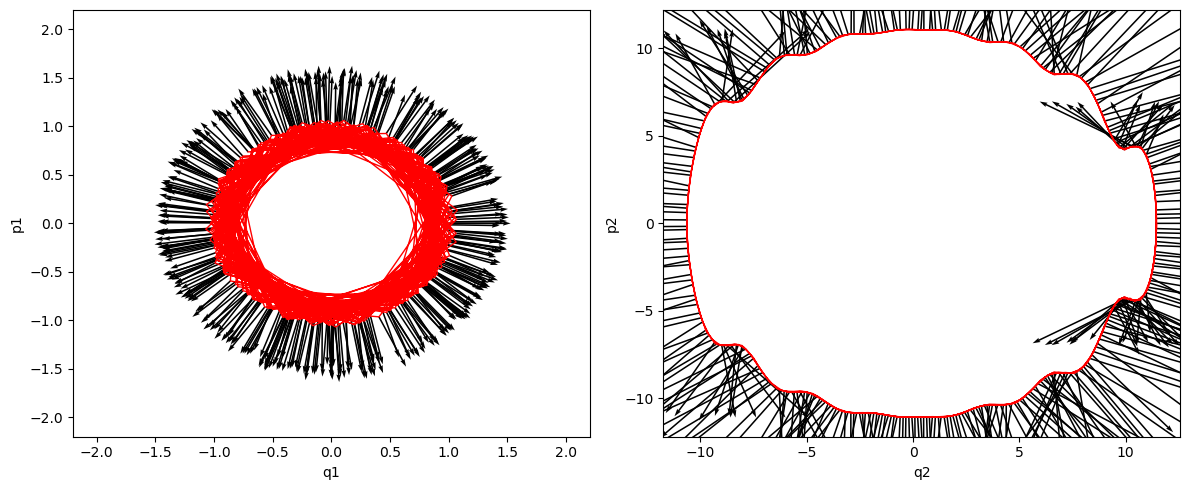

In [58]:
epsilon = 0.01
u_ref = u_ref2 
grad_H = grad_H2

indices_ref = np.arange(len(u_ref1))[::100]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(u_ref[indices_ref, 2], u_ref[indices_ref, 0], "-", lw=1, color="r")
plt.quiver(u_ref[indices_ref, 2], u_ref[indices_ref, 0], 
            grad_H[indices_ref, 2], grad_H[indices_ref, 0], scale=10)
plt.xlim(-2.2, 2.2)
plt.ylim(-2.2, 2.2)
plt.xlabel("q1")
plt.ylabel("p1")
# plt.legend()

plt.subplot(1, 2, 2)
plt.plot(u_ref[indices_ref, 3], u_ref[indices_ref, 1]/epsilon, "-", lw=1, color="r")
plt.quiver(u_ref[indices_ref, 3], u_ref[indices_ref, 1]/epsilon, 
            grad_H[indices_ref, 3], grad_H[indices_ref, 1], scale=0.5)
# plt.xlim(-2., 2)
# plt.ylim(-0.018, 0.018)
plt.xlabel("q2")
plt.ylabel("p2")
# plt.legend()

plt.tight_layout()
plt.show()

## Numerical solutions

In [6]:
import sys
sys.path.append("../deep_learning/src")

import torch
from utils.integrator_utils import instantiate_dynamical_ode_integrator
from problems.nco import NonlinearCoupledOscillators


In [7]:
def run_simulations(u0, method, h, nsteps):

    EPSILON = 0.01

    nco = NonlinearCoupledOscillators(epsilon=EPSILON)
    integrator = instantiate_dynamical_ode_integrator(method, h, 1, nco.compute_ddx)
    
    v0, x0 = u0.chunk(2, dim=-1)
    t0 = torch.zeros(len(u0), 1, dtype=torch.float64)
    V, X, _ = integrator.integrate(v0, x0, t0, nsteps, retfull=True)
    U = torch.concatenate([V, X], dim=-1)
    
    times = np.arange(0, nsteps+1) * h
    simulated_trajs = []
    for i in range(len(u0)):
        traj = Trajectory.from_vx(times, U[:, i, :].numpy(), epsilon=EPSILON)
        simulated_trajs.append(traj)
    
    return simulated_trajs

In [8]:
traj_indices = [1, 12, 11]
method = "VelocityVerlet"
# h_list = [0.025, 0.05, 0.1, 0.2, 0.4, 0.8]
h_list = [0.05, 0.1, 0.2]
T_end = 10

ref_trajs = [Trajectory.load_from_file(REF_TRAJ_FILEPATHS[idx], REF_TRAJ_DT) for idx in traj_indices]
u0 = torch.tensor(np.array([traj.states.u[0] for traj in ref_trajs]))
results = []
for h in h_list:
    simulated_trajs = run_simulations(u0, method, h, int(T_end / h))
    results.append(simulated_trajs)

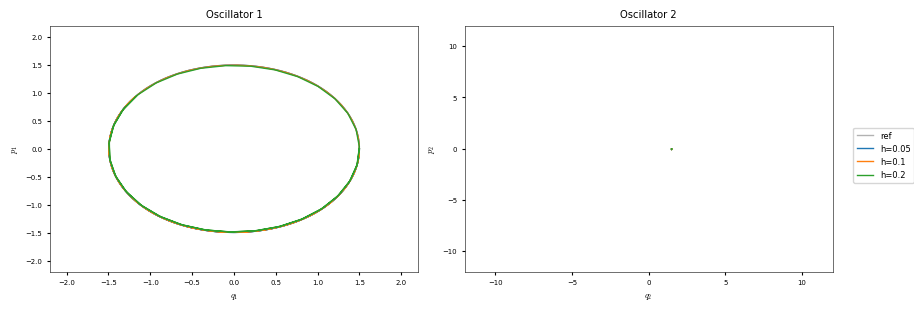

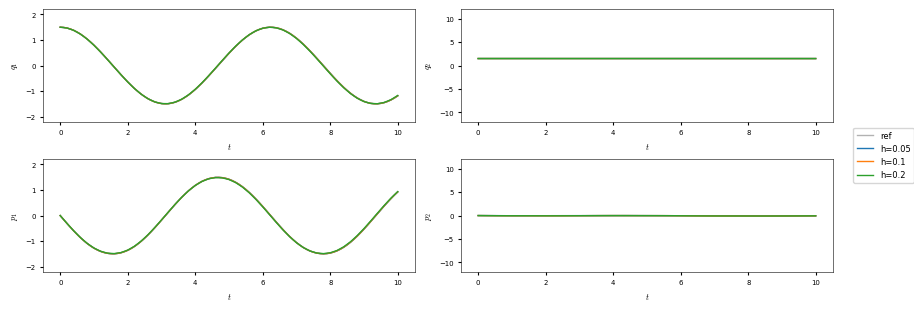

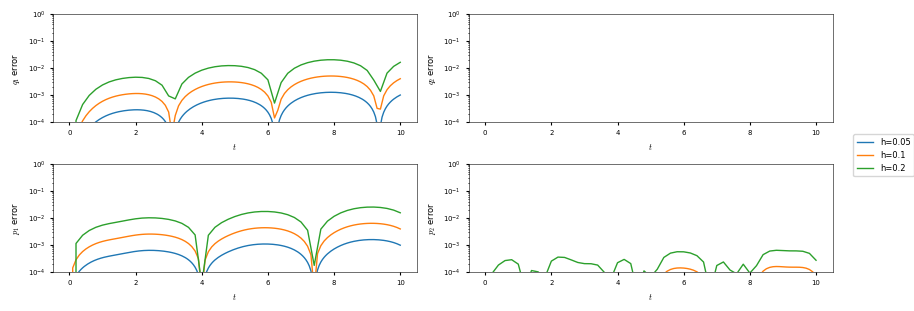

After alignment: 
	traj = NCOTrajectory(t_range=[0.0, 10.0], dt=0.05, u0=[0.  0.  1.5 1.5], states=States(problem=NCO(epsilon=0.01), shape=(201, 4)))
	ref_traj = NCOTrajectory(t_range=[0.0, 10.0], dt=0.05, u0=[0.  0.  1.5 1.5], states=States(problem=NCO(epsilon=0.01), shape=(201, 4)))
After alignment: 
	traj = NCOTrajectory(t_range=[0.0, 10.0], dt=0.1, u0=[0.  0.  1.5 1.5], states=States(problem=NCO(epsilon=0.01), shape=(101, 4)))
	ref_traj = NCOTrajectory(t_range=[0.0, 10.0], dt=0.1, u0=[0.  0.  1.5 1.5], states=States(problem=NCO(epsilon=0.01), shape=(101, 4)))
After alignment: 
	traj = NCOTrajectory(t_range=[0.0, 10.0], dt=0.2, u0=[0.  0.  1.5 1.5], states=States(problem=NCO(epsilon=0.01), shape=(51, 4)))
	ref_traj = NCOTrajectory(t_range=[0.0, 10.0], dt=0.2, u0=[0.  0.  1.5 1.5], states=States(problem=NCO(epsilon=0.01), shape=(51, 4)))


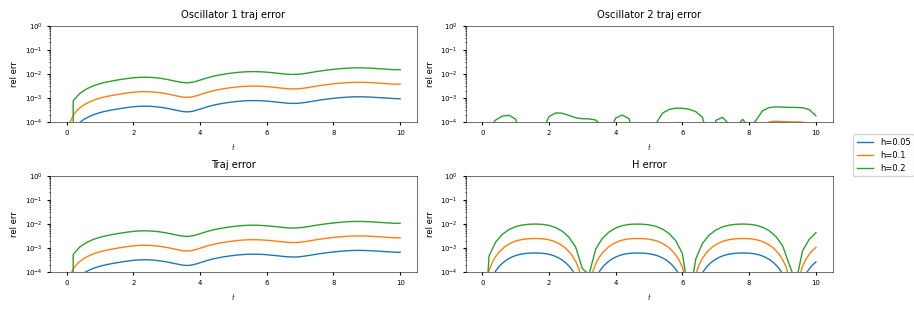

After alignment: 
	traj = NCOTrajectory(t_range=[0.0, 10.0], dt=0.05, u0=[0.  0.  1.5 1.5], states=States(problem=NCO(epsilon=0.01), shape=(201, 4)))
	ref_traj = NCOTrajectory(t_range=[0.0, 10.0], dt=0.05, u0=[0.  0.  1.5 1.5], states=States(problem=NCO(epsilon=0.01), shape=(201, 4)))
h=0.05:
	osc1_rel_traj_err=0.0009159973181653135
	osc2_rel_traj_err=1.1767719902926034e-05
	rel_traj_err=0.0006490939040133126
	rel_H_err=0.0002561427636539413
After alignment: 
	traj = NCOTrajectory(t_range=[0.0, 10.0], dt=0.1, u0=[0.  0.  1.5 1.5], states=States(problem=NCO(epsilon=0.01), shape=(101, 4)))
	ref_traj = NCOTrajectory(t_range=[0.0, 10.0], dt=0.1, u0=[0.  0.  1.5 1.5], states=States(problem=NCO(epsilon=0.01), shape=(101, 4)))
h=0.1:
	osc1_rel_traj_err=0.0036657415119185064
	osc2_rel_traj_err=4.660835330363304e-05
	rel_traj_err=0.002597612931543789
	rel_H_err=0.0010333493788586934
After alignment: 
	traj = NCOTrajectory(t_range=[0.0, 10.0], dt=0.2, u0=[0.  0.  1.5 1.5], states=States(problem=

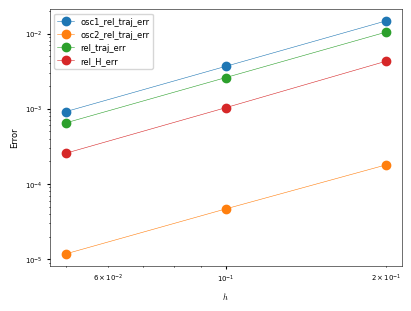

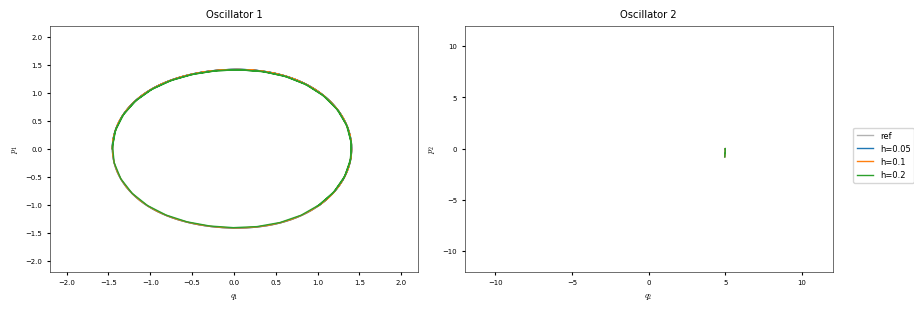

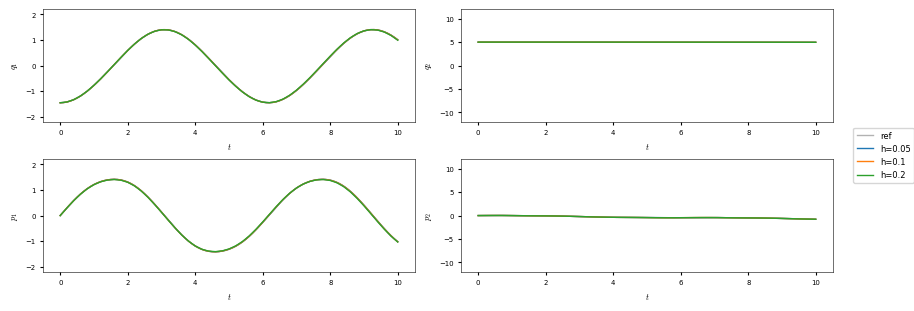

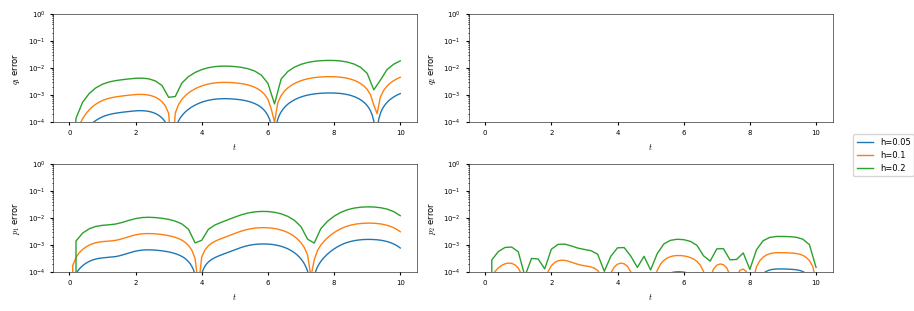

After alignment: 
	traj = NCOTrajectory(t_range=[0.0, 10.0], dt=0.05, u0=[ 0.       0.      -1.45433  5.     ], states=States(problem=NCO(epsilon=0.01), shape=(201, 4)))
	ref_traj = NCOTrajectory(t_range=[0.0, 10.0], dt=0.05, u0=[ 0.       0.      -1.45433  5.     ], states=States(problem=NCO(epsilon=0.01), shape=(201, 4)))
After alignment: 
	traj = NCOTrajectory(t_range=[0.0, 10.0], dt=0.1, u0=[ 0.       0.      -1.45433  5.     ], states=States(problem=NCO(epsilon=0.01), shape=(101, 4)))
	ref_traj = NCOTrajectory(t_range=[0.0, 10.0], dt=0.1, u0=[ 0.       0.      -1.45433  5.     ], states=States(problem=NCO(epsilon=0.01), shape=(101, 4)))
After alignment: 
	traj = NCOTrajectory(t_range=[0.0, 10.0], dt=0.2, u0=[ 0.       0.      -1.45433  5.     ], states=States(problem=NCO(epsilon=0.01), shape=(51, 4)))
	ref_traj = NCOTrajectory(t_range=[0.0, 10.0], dt=0.2, u0=[ 0.       0.      -1.45433  5.     ], states=States(problem=NCO(epsilon=0.01), shape=(51, 4)))


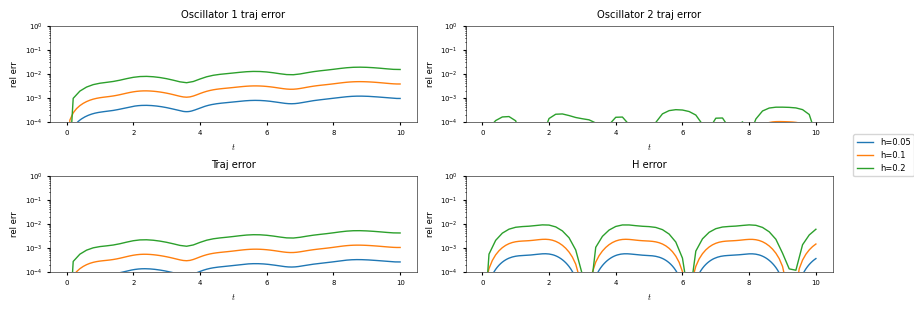

After alignment: 
	traj = NCOTrajectory(t_range=[0.0, 10.0], dt=0.05, u0=[ 0.       0.      -1.45433  5.     ], states=States(problem=NCO(epsilon=0.01), shape=(201, 4)))
	ref_traj = NCOTrajectory(t_range=[0.0, 10.0], dt=0.05, u0=[ 0.       0.      -1.45433  5.     ], states=States(problem=NCO(epsilon=0.01), shape=(201, 4)))
h=0.05:
	osc1_rel_traj_err=0.0009358314265206128
	osc2_rel_traj_err=2.3900206809170356e-06
	rel_traj_err=0.0002571955155995778
	rel_H_err=0.0003558936490933391
After alignment: 
	traj = NCOTrajectory(t_range=[0.0, 10.0], dt=0.1, u0=[ 0.       0.      -1.45433  5.     ], states=States(problem=NCO(epsilon=0.01), shape=(101, 4)))
	ref_traj = NCOTrajectory(t_range=[0.0, 10.0], dt=0.1, u0=[ 0.       0.      -1.45433  5.     ], states=States(problem=NCO(epsilon=0.01), shape=(101, 4)))
h=0.1:
	osc1_rel_traj_err=0.0037455465990502254
	osc2_rel_traj_err=9.10142136390981e-06
	rel_traj_err=0.0010293885405213748
	rel_H_err=0.0014336654501851365
After alignment: 
	traj = NCOTraj

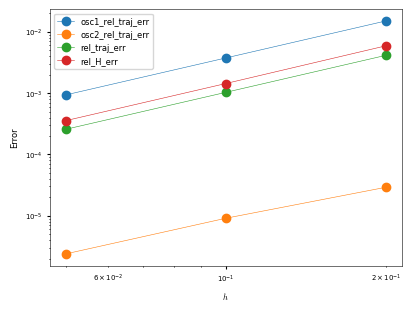

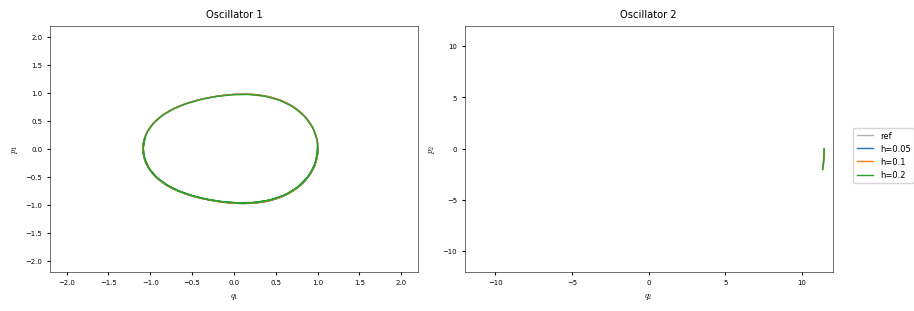

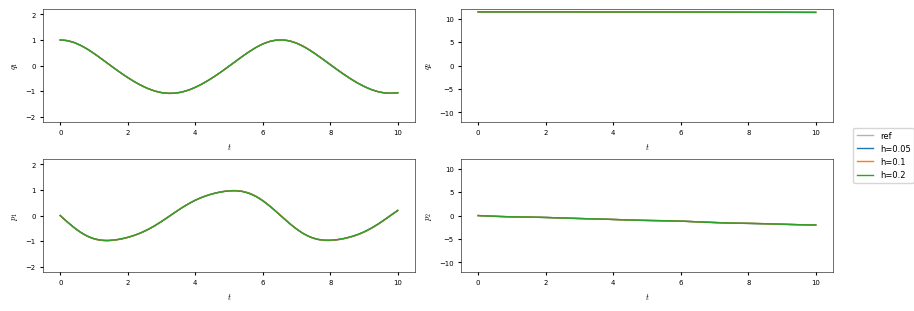

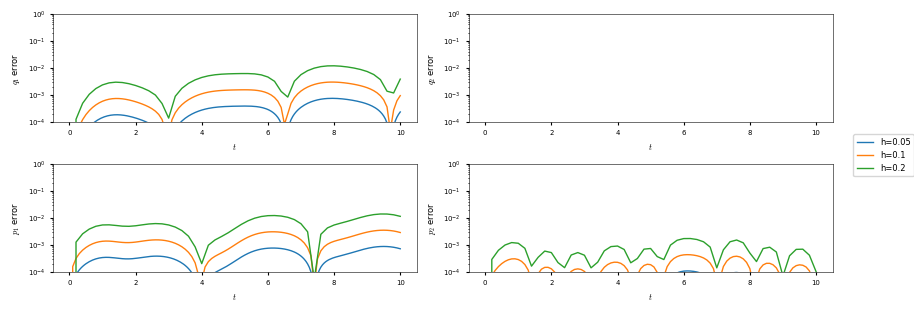

After alignment: 
	traj = NCOTrajectory(t_range=[0.0, 10.0], dt=0.05, u0=[ 0.       0.       1.      11.45256], states=States(problem=NCO(epsilon=0.01), shape=(201, 4)))
	ref_traj = NCOTrajectory(t_range=[0.0, 10.0], dt=0.05, u0=[ 0.       0.       1.      11.45256], states=States(problem=NCO(epsilon=0.01), shape=(201, 4)))
After alignment: 
	traj = NCOTrajectory(t_range=[0.0, 10.0], dt=0.1, u0=[ 0.       0.       1.      11.45256], states=States(problem=NCO(epsilon=0.01), shape=(101, 4)))
	ref_traj = NCOTrajectory(t_range=[0.0, 10.0], dt=0.1, u0=[ 0.       0.       1.      11.45256], states=States(problem=NCO(epsilon=0.01), shape=(101, 4)))
After alignment: 
	traj = NCOTrajectory(t_range=[0.0, 10.0], dt=0.2, u0=[ 0.       0.       1.      11.45256], states=States(problem=NCO(epsilon=0.01), shape=(51, 4)))
	ref_traj = NCOTrajectory(t_range=[0.0, 10.0], dt=0.2, u0=[ 0.       0.       1.      11.45256], states=States(problem=NCO(epsilon=0.01), shape=(51, 4)))


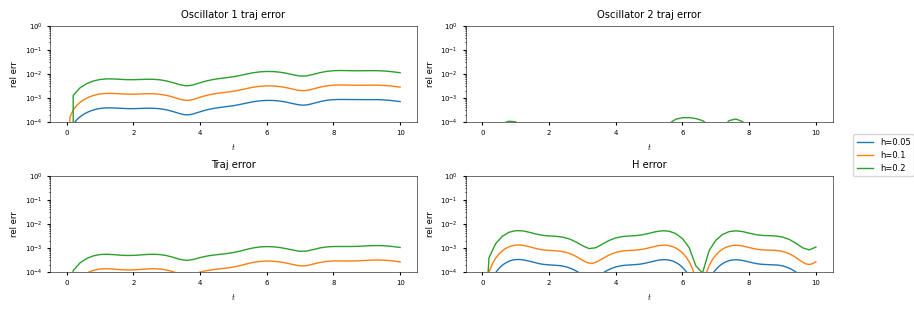

After alignment: 
	traj = NCOTrajectory(t_range=[0.0, 10.0], dt=0.05, u0=[ 0.       0.       1.      11.45256], states=States(problem=NCO(epsilon=0.01), shape=(201, 4)))
	ref_traj = NCOTrajectory(t_range=[0.0, 10.0], dt=0.05, u0=[ 0.       0.       1.      11.45256], states=States(problem=NCO(epsilon=0.01), shape=(201, 4)))
h=0.05:
	osc1_rel_traj_err=0.0006923044558350055
	osc2_rel_traj_err=3.6422242274127163e-07
	rel_traj_err=6.469557510866124e-05
	rel_H_err=6.434596253272674e-05
After alignment: 
	traj = NCOTrajectory(t_range=[0.0, 10.0], dt=0.1, u0=[ 0.       0.       1.      11.45256], states=States(problem=NCO(epsilon=0.01), shape=(101, 4)))
	ref_traj = NCOTrajectory(t_range=[0.0, 10.0], dt=0.1, u0=[ 0.       0.       1.      11.45256], states=States(problem=NCO(epsilon=0.01), shape=(101, 4)))
h=0.1:
	osc1_rel_traj_err=0.002766911004325625
	osc2_rel_traj_err=1.6489511424336464e-06
	rel_traj_err=0.00025856787931620293
	rel_H_err=0.0002589907326661073
After alignment: 
	traj = NCOTr

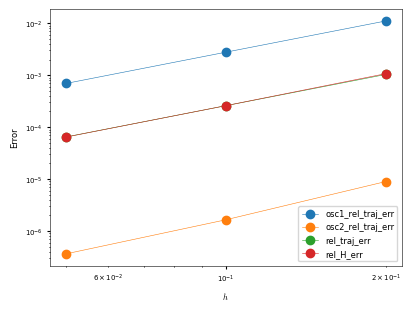

In [ ]:
for traj_idx in [1, 12, 11]: 
    t_range = (0, 10)
    idx = traj_indices.index(traj_idx)
    trajs = [ref_trajs[idx].select_between(*t_range)] + [simulated_trajs[idx].select_between(*t_range) for simulated_trajs in results]
    legend_labels = ["ref"] + [f"h={h}" for h in h_list]

    # phase_space_axis_lims = [[(-2.2, 2.2), (-2.2, 2.2)], [(-1, 1.6), (-1.6, 1.6)]]
    phase_space_axis_lims = [[(-2.2, 2.2), (-2.2, 2.2)], [(-12, 12), (-12, 12)]]
    plot_phase_space(trajs, axis_lims=phase_space_axis_lims, 
                        legend_labels=legend_labels, show_legend=True)

    q1_lim, p1_lim = phase_space_axis_lims[0]
    q2_lim, p2_lim = phase_space_axis_lims[1]
    plot_pq_vs_t(trajs, ylims=[q1_lim, q2_lim, p1_lim, p2_lim],
                    legend_labels=legend_labels, show_legend=True)
    plot_pq_errors(trajs[1:], trajs[0], ylims=[(1e-4, 1e-1), (1e-5, 1e-1), (1e-4, 1e-1), (1e-5, 1e-1)],
                   legend_labels=legend_labels[1:], show_legend=True)
    plot_errors(trajs[1:], trajs[0], legend_labels=legend_labels[1:], show_legend=True)

    error_names = ["osc1_rel_traj_err", "osc2_rel_traj_err", "rel_traj_err", "rel_H_err"]
    final_errors = {error_name: [] for error_name in error_names}
    for traj, h in zip(trajs[1:], h_list):
        tt, errors = Trajectory.compare(traj, trajs[0])
        print(f"h={h}:")
        for error_name in error_names:
            print(f"\t{error_name}={errors[error_name][-1]}")
            final_errors[error_name].append(errors[error_name][-1])

    fig, ax = plt.subplots(1, 1, figsize=(4, 3), layout='constrained')
    for error_name in error_names:
        ax.loglog(h_list, final_errors[error_name], 'o-', label=error_name)
    plt.xlabel('$h$')
    plt.ylabel('Error')
    plt.legend()
    plt.show()